In [80]:
from automata.fa.nfa import NFA
from automata.fa.dfa import DFA

input_states = input("Enter set of states:").split(" ")
input_symbols = input("Enter set of input symbols:").split(" ")
transitions = {}
builder = {}
for state in input_states:
    for symbol in input_symbols:
        hold = set(input("Enter next states for symbol " + symbol + " on the state " + state + ":").split(" "))
        if hold != {''}:
            builder[symbol] = hold 
    transitions[state] = builder
    builder = {}
initial_state = input("Enter initial state:")
final_states = input("Enter set of final states state:").split(" ")
my_nfa = NFA(
    states=set(input_states),
    input_symbols=set(input_symbols),
    transitions=transitions,
    initial_state=initial_state,
    final_states=set(final_states),
)

Enter set of states: 1 2 3 4 5 6
Enter set of input symbols: a b
Enter next states for symbol a on the state 1: 2
Enter next states for symbol b on the state 1: 4
Enter next states for symbol a on the state 2: 4
Enter next states for symbol b on the state 2: 3
Enter next states for symbol a on the state 3: 3
Enter next states for symbol b on the state 3: 3
Enter next states for symbol a on the state 4: 4
Enter next states for symbol b on the state 4: 5
Enter next states for symbol a on the state 5: 5
Enter next states for symbol b on the state 5: 5
Enter next states for symbol a on the state 6: 6
Enter next states for symbol b on the state 6: 5
Enter initial state: 1
Enter set of final states state: 3 5


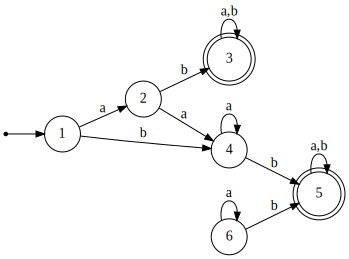

In [81]:
my_nfa.show_diagram()

In [82]:
indis = [[1 for i in range(len(input_states) - 1)] for j in range(len(input_states) - 1)]
indis

[[1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1]]

In [83]:
indis = [[0 for i in range(len(input_states) - 1)] for j in range(len(input_states) - 1)]

In [84]:
indis[4][1]= 1

In [85]:
indis[2][1]= 1

In [86]:
indis[3][2]= 1

In [87]:
indis[4][3]= 1

In [88]:
for state_x in indis:
    print(state_x)

[0, 0, 0, 0, 0]
[0, 0, 0, 0, 0]
[0, 1, 0, 0, 0]
[0, 0, 1, 0, 0]
[0, 1, 0, 1, 0]


In [99]:
push = 1
state_list = list(input_states)
states = {}
added = False
for y in range(len(indis)):
    for x in range(push):
        if indis[y][x] == 1:
            added = True
            if state_list[y+1] in states:
                states[state_list[y+1]].add(state_list[x])
            else:
                states[state_list[y+1]] = {state_list[x]}
    push += 1
    if not added:
        if y == 0:
            states[state_list[y]] = {}
        else:
            states[state_list[y+1]] = {}
    added = False
print(states)

{'1': {}, '3': {}, '4': {'2'}, '5': {'3'}, '6': {'2', '4'}}


In [100]:
new_states = []
curr = set()
for curr_state in states:
    curr.add(curr_state)
    for state in states:
        for substate in states[state]:
            if state in curr or substate in curr:
                curr.add(state)
                addall = True
            if addall:
                curr.add(substate)
        addall = False
    if curr not in new_states:
        new_states.append(curr)
    curr = set()
print(new_states)

[{'1'}, {'5', '3'}, {'2', '6', '4'}]


In [112]:
new_state = []
new_final = []
new_ini = False
new_fin = False
for state in new_states:
    hold = ""
    for prev in state:
        if prev == initial_state:
            new_ini = True
        if prev in final_states:
            new_fin = True
        hold = hold + prev
    if new_ini:
        new_ini = not new_ini
        new_initial = hold
    if new_fin:
        new_fin = not new_fin
        new_final.append(hold)
    new_state.append(hold)
new_state

['1', '53', '264']

In [124]:
transitions

{'1': {'a': {'2'}, 'b': {'4'}},
 '2': {'a': {'4'}, 'b': {'3'}},
 '3': {'a': {'3'}, 'b': {'3'}},
 '4': {'a': {'4'}, 'b': {'5'}},
 '5': {'a': {'5'}, 'b': {'5'}},
 '6': {'a': {'6'}, 'b': {'5'}}}

In [122]:
new_transitions = {'1': {'a':{'264'}, 'b': {'264'}}, '264' : {'a':{'264'},'b':{'53'}},'53':{'a':{'53'},'b':{'53'}}}

In [125]:
new_nfa = NFA(
    states=set(new_state),
    input_symbols=set(input_symbols),
    transitions=new_transitions,
    initial_state=new_initial,
    final_states=set(new_final),
)

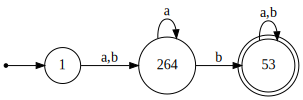

In [126]:
new_nfa.show_diagram()